In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(4)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df[df.duplicated()].sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
cols_to_drop = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=cols_to_drop, inplace=True)

In [7]:
df.shape

(1470, 31)

In [8]:
# Salary Band
df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 4000, 8000, 20000],
    labels=['Low', 'Medium', 'High']
)

# Age Group
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 40, 50, 60],
    labels=['18-30', '31-40', '41-50', '51-60']
)

# Tenure Group
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 40],
    labels=['0-2', '3-5', '6-10', '10+']
)

In [12]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,SalaryBand,AgeGroup,TenureGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,8,0,1,6,4,0,5,Medium,41-50,6-10
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,10,3,3,10,7,1,7,Medium,41-50,6-10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,7,3,3,0,0,0,0,Low,31-40,NaN
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,8,3,3,8,7,3,0,Low,31-40,6-10
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,6,3,3,2,2,2,2,Low,18-30,0-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,17,3,3,5,2,0,3,Low,31-40,3-5
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,9,5,3,7,7,1,7,High,31-40,6-10
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,6,0,3,6,2,0,3,Medium,18-30,6-10
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,17,3,2,9,6,0,8,Medium,41-50,6-10


In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

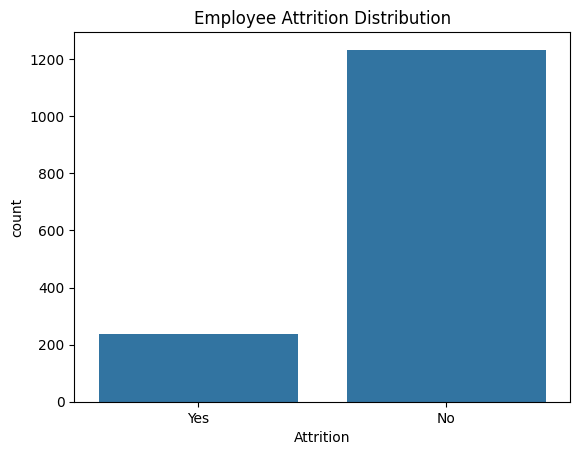

In [11]:
import seaborn as sns

sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Distribution')
plt.show()

In [12]:
pd.crosstab(df['Department'], df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [13]:
(
    pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
).round(2)

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


In [14]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [15]:
(
    pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
).round(2)

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


In [16]:
(
    pd.crosstab(
        df['JobSatisfaction'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

Attrition,No,Yes
JobSatisfaction,,
1,77.16,22.84
2,83.57,16.43
3,83.48,16.52
4,88.67,11.33


In [17]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [18]:
(
    pd.crosstab(
        df['WorkLifeBalance'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.78,14.22
4,82.35,17.65


In [19]:
(
    pd.crosstab(
        df['YearsSinceLastPromotion'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2)

Attrition,No,Yes
YearsSinceLastPromotion,,
0,81.07,18.93
1,86.27,13.73
2,83.02,16.98
3,82.69,17.31
4,91.80,8.20
5,95.56,4.44
6,81.25,18.75
7,78.95,21.05
8,100.00,0.00


In [20]:
df.groupby('Attrition')['YearsSinceLastPromotion'].mean()

Attrition
No     2.234388
Yes    1.945148
Name: YearsSinceLastPromotion, dtype: float64

| Factor            | Evidence           | Impact |
| ----------------- | ------------------ | ------ |
| Overtime          | 30.53% vs 10.44%   | High   |
| Work-Life Balance | 31.25% vs 14.22%   | High   |
| Job Satisfaction  | 22.84% vs 11.33%   | Medium |
| Salary            | 4787 vs 6832       | High   |
| Promotion         | 1.95 vs 2.23 years | Low    |


In [21]:
df.groupby('Attrition')['Age'].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

In [22]:
(
    pd.crosstab(
        df['JobRole'],
        df['Attrition'],
        normalize='index'
    ) * 100
).round(2).sort_values('Yes', ascending=False)

Attrition,No,Yes
JobRole,,
Sales Representative,60.24,39.76
Laboratory Technician,76.06,23.94
Human Resources,76.92,23.08
Sales Executive,82.52,17.48
Research Scientist,83.90,16.10
Manufacturing Director,93.10,6.90
Healthcare Representative,93.13,6.87
Manager,95.10,4.90
Research Director,97.50,2.50


Finding 1:
Attrition Rate = 16.12%

Finding 2:
Overtime employees have 30.53% attrition compared to 10.44% for non-overtime employees.

Finding 3:
Employees with poor work-life balance have 31.25% attrition.

Finding 4:
Employees who left earned 30% less on average.

Finding 5:
Average age of employees leaving is 33.6 years compared to 37.6 years for retained employees.

Finding 6:
Sales Representatives have the highest attrition rate at 39.76%.

In [23]:
total_employees = len(df)
total_employees

1470

In [24]:
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
round(attrition_rate, 2)

np.float64(16.12)

In [25]:
avg_salary = round(df['MonthlyIncome'].mean(), 2)
avg_salary

np.float64(6502.93)

In [26]:
avg_age = round(df['Age'].mean(), 2)
avg_age

np.float64(36.92)

In [27]:
avg_tenure = round(df['YearsAtCompany'].mean(), 2)
avg_tenure

np.float64(7.01)

In [31]:
df.to_csv("HR_Analytics_Cleaned.csv", index=False)